# 02 - Conversion funnel analysis

## Business question

The most pressing question for e-commerce: **how much does each behavior step drop off? Which step has the biggest loss?**

In this dataset, the 4 behaviors (browse/favorite/cart/purchase) form a natural funnel. But we must choose the right measurement:
- **Unique users**: how many distinct users reached each stage
- **Event counts**: how many total events occurred at each stage

These give different pictures. I will use **event counts** as the primary measure because it captures the "funnel pressure" at each step (a user who browsed 1000 times but bought once represents real funnel stress).

**Goals**:
1. Draw the 4-step event-count funnel
2. Find the biggest drop-off step
3. Do **attribution analysis** on drop-off users (only browse, no purchase)
4. Give 3 actionable operation recommendations

In [1]:
import sys
sys.path.append('../scripts')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils import load_data, setup_plot_style, save_fig, BEHAVIOR_LABELS, BEHAVIOR_COLORS

setup_plot_style()
df = load_data()
print(f"Loaded: {len(df):,} rows")

Loaded: 12,256,906 rows


Event-count funnel (total events at each stage):
  浏览: 11,550,581 events (100.0000%)
  收藏: 242,556 events (2.0999%)
  加购: 343,564 events (2.9744%)
  购买: 120,205 events (1.0407%)
  -> saved: images/02_overall_funnel.png


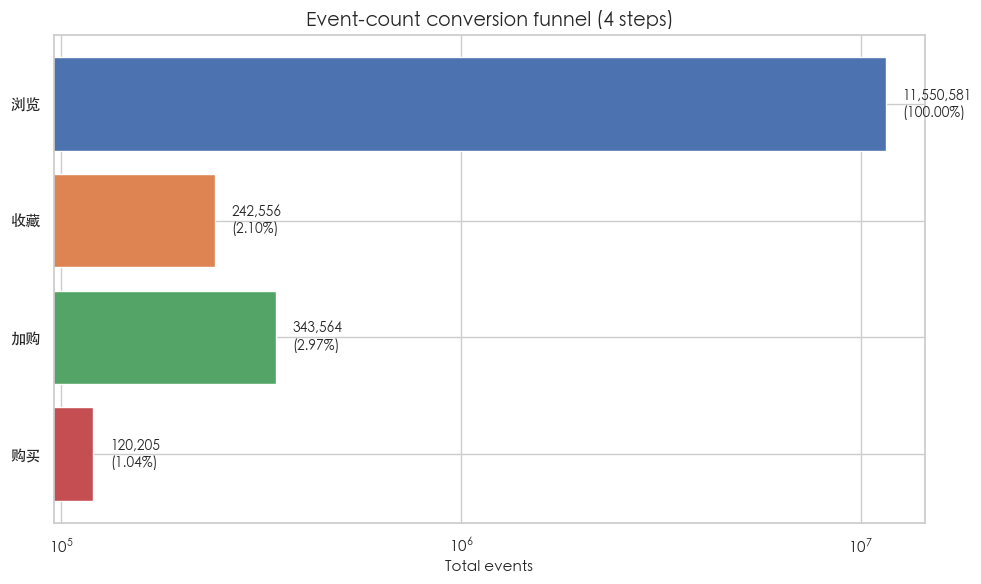

In [2]:
# Event-count funnel: total events at each behavior type
event_funnel = df['behavior_type'].value_counts().sort_index()
event_funnel.index = event_funnel.index.map(BEHAVIOR_LABELS)

browse_events = event_funnel['浏览']
event_conversions = pd.Series({
    '浏览': 100.0,
    '收藏': event_funnel['收藏'] / browse_events * 100,
    '加购': event_funnel['加购'] / browse_events * 100,
    '购买': event_funnel['购买'] / browse_events * 100,
})

print("Event-count funnel (total events at each stage):")
for stage, n in event_funnel.items():
    print(f"  {stage}: {n:,} events ({event_conversions[stage]:.4f}%)")

# Funnel chart
fig, ax = plt.subplots()
y_pos = range(len(event_funnel))
heights = event_funnel.values
colors = [BEHAVIOR_COLORS[s] for s in event_funnel.index]

bars = ax.barh(y_pos, heights, color=colors)
ax.set_yticks(y_pos)
ax.set_yticklabels(event_funnel.index)
ax.invert_yaxis()
ax.set_title("Event-count conversion funnel (4 steps)")
ax.set_xlabel("Total events")
ax.set_xscale('log')

for i, (stage, val) in enumerate(event_funnel.items()):
    ax.text(val * 1.1, i, f"{val:,}\n({event_conversions[stage]:.2f}%)",
            va='center', fontsize=10)

save_fig(fig, "02_overall_funnel")
plt.show()

In [3]:
# Drop-off rate between consecutive steps
print("Drop-off analysis (event counts):")
prev = None
dropoffs = []
for stage, n in event_funnel.items():
    if prev is not None:
        drop = (prev - n) / prev * 100
        print(f"  {prev_stage} -> {stage}: drop {drop:.2f}%")
        dropoffs.append((prev_stage, stage, drop))
    prev = n
    prev_stage = stage

max_drop = max(dropoffs, key=lambda x: x[2])
print(f"\nBiggest drop step: {max_drop[0]} -> {max_drop[1]} (drop {max_drop[2]:.2f}%)")

Drop-off analysis (event counts):
  浏览 -> 收藏: drop 97.90%
  收藏 -> 加购: drop -41.64%
  加购 -> 购买: drop 65.01%

Biggest drop step: 浏览 -> 收藏 (drop 97.90%)


In [4]:
# Per-user behavior intensity (events per user)
user_events = df.groupby(['user_id', 'behavior_type']).size().unstack(fill_value=0)
user_events.columns = user_events.columns.map(lambda x: BEHAVIOR_LABELS[x] if x in BEHAVIOR_LABELS else x)

print("Events per active user:")
for col in ['浏览', '收藏', '加购', '购买']:
    if col in user_events.columns:
        active = user_events[user_events[col] > 0]
        print(f"  {col}: mean {active[col].mean():.1f} events/user, median {active[col].median():.0f}")

# Active users per stage
print("\nActive users per stage:")
for bt in [1,2,3,4]:
    n = df[df['behavior_type']==bt]['user_id'].nunique()
    label = BEHAVIOR_LABELS[bt]
    print(f"  {label}: {n:,} unique users")

Events per active user:
  浏览: mean 1155.1 events/user, median 703
  收藏: mean 36.0 events/user, median 8
  加购: mean 39.9 events/user, median 17
  购买: mean 13.5 events/user, median 8

Active users per stage:


  浏览: 10,000 unique users
  收藏: 6,730 unique users
  加购: 8,614 unique users
  购买: 8,886 unique users


  -> saved: images/02_funnel_by_hour.png


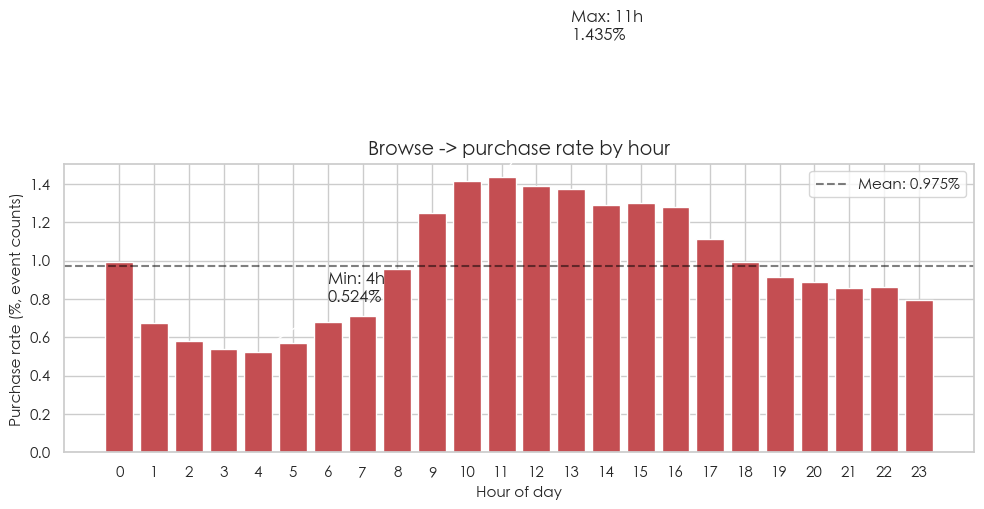

In [5]:
# Funnel breakdown by hour (event counts)
funnel_by_hour = df.groupby([df['time'].dt.hour, 'behavior_type']).size().unstack(fill_value=0)
funnel_by_hour.columns = funnel_by_hour.columns.map(BEHAVIOR_LABELS)
funnel_by_hour = funnel_by_hour[['浏览', '收藏', '加购', '购买']]
funnel_by_hour['购买转化率%'] = funnel_by_hour['购买'] / funnel_by_hour['浏览'] * 100

fig, ax = plt.subplots()
ax.bar(funnel_by_hour.index, funnel_by_hour['购买转化率%'], color='#C44E52', edgecolor='white')
ax.set_title("Browse -> purchase rate by hour")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Purchase rate (%, event counts)")
ax.set_xticks(range(0, 24))
mean_rate = funnel_by_hour['购买转化率%'].mean()
ax.axhline(mean_rate, color='black', linestyle='--', alpha=0.5,
           label=f"Mean: {mean_rate:.3f}%")
ax.legend()

max_hr = funnel_by_hour['购买转化率%'].idxmax()
min_hr = funnel_by_hour['购买转化率%'].idxmin()
ax.annotate(f"Max: {max_hr}h\n{funnel_by_hour.loc[max_hr, '购买转化率%']:.3f}%",
            xy=(max_hr, funnel_by_hour.loc[max_hr, '购买转化率%']),
            xytext=(max_hr + 2, funnel_by_hour.loc[max_hr, '购买转化率%'] * 1.5),
            arrowprops=dict(arrowstyle='->'))
ax.annotate(f"Min: {min_hr}h\n{funnel_by_hour.loc[min_hr, '购买转化率%']:.3f}%",
            xy=(min_hr, funnel_by_hour.loc[min_hr, '购买转化率%']),
            xytext=(min_hr + 2, funnel_by_hour.loc[min_hr, '购买转化率%'] * 1.5),
            arrowprops=dict(arrowstyle='->'))

save_fig(fig, "02_funnel_by_hour")
plt.show()

  -> saved: images/02_funnel_by_category.png


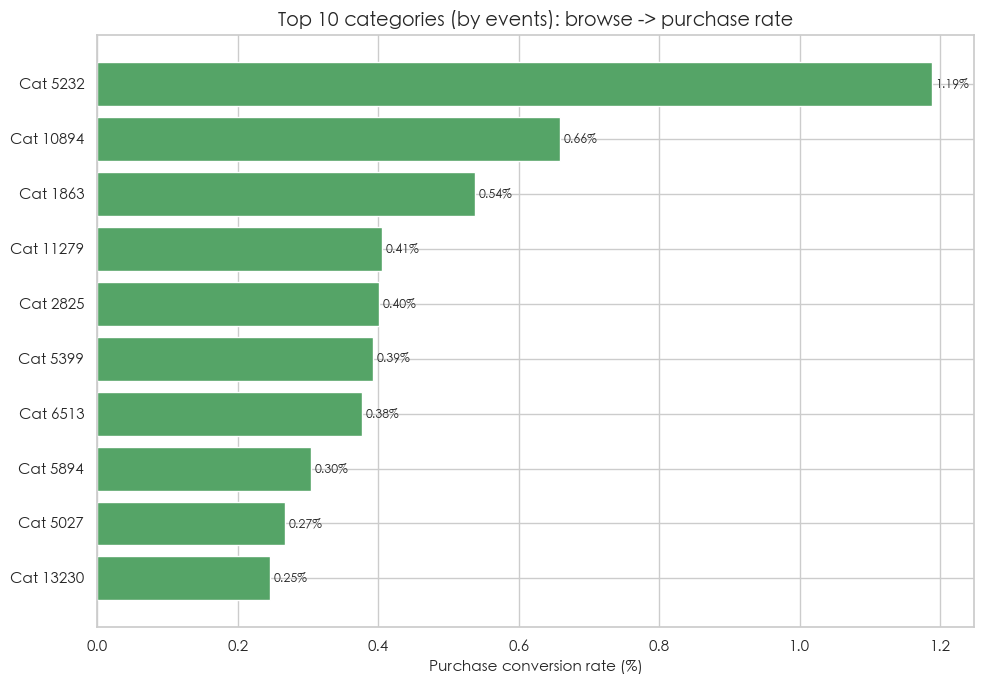

In [6]:
# Top 10 categories by event count
top_cats = df['item_category'].value_counts().nlargest(10).index
df_top = df[df['item_category'].isin(top_cats)]

funnel_by_cat = df_top.groupby(['item_category', 'behavior_type']).size().unstack(fill_value=0)
funnel_by_cat.columns = funnel_by_cat.columns.map(BEHAVIOR_LABELS)
funnel_by_cat = funnel_by_cat[['浏览', '收藏', '加购', '购买']]
funnel_by_cat['购买率%'] = funnel_by_cat['购买'] / funnel_by_cat['浏览'] * 100
funnel_by_cat = funnel_by_cat.sort_values('购买率%', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(len(funnel_by_cat)), funnel_by_cat['购买率%'], color='#55A467')
ax.set_yticks(range(len(funnel_by_cat)))
ax.set_yticklabels([f"Cat {c}" for c in funnel_by_cat.index])
ax.invert_yaxis()
ax.set_title("Top 10 categories (by events): browse -> purchase rate")
ax.set_xlabel("Purchase conversion rate (%)")
for i, v in enumerate(funnel_by_cat['购买率%']):
    ax.text(v + 0.005, i, f"{v:.2f}%", va='center', fontsize=9)
save_fig(fig, "02_funnel_by_category")
plt.show()

## Hypothesis-driven drop-off attribution

In real analysis, I don't just look at numbers — I **start with hypotheses and verify them with data**. This section walks through 2 hypotheses I held about the drop-off users, and how each was verified or refuted.

### Hypothesis 1: Drop-off users are "window shoppers" (low intent)

**Hypothesis**: Users who never purchase are passive browsers — they have low browse intensity and rarely engage with cart.

**Verification metrics**:
- Browse intensity (total browse events)
- Browse depth (distinct items)
- Add-to-cart rate

**Data results**: see code cell below.

### Hypothesis 2: Drop-off users have scattered category engagement

**Hypothesis**: Users who never purchase browse across many unrelated categories (decision paralysis), while converting users focus on a few categories of interest.

**Verification metric**: category breadth — number of distinct categories browsed / total category pool.

In [7]:
# Define user groups
purchased_users = set(df[df['behavior_type'] == 4]['user_id'].unique())
all_users = set(df['user_id'].unique())
browse_only_users = all_users - purchased_users

print(f"Drop-off users (browse only, no purchase): {len(browse_only_users):,}")
print(f"Converting users (purchased at least once): {len(purchased_users):,}")
print(f"Drop-off rate: {len(browse_only_users)/len(all_users)*100:.2f}%")

# Dimension 1: browse intensity (total browse events)
user_browse_count = df[df['behavior_type'] == 1].groupby('user_id').size()
count_lost = user_browse_count[user_browse_count.index.isin(browse_only_users)]
count_conv = user_browse_count[user_browse_count.index.isin(purchased_users)]

print(f"\nBrowse intensity (total browse events):")
print(f"  Drop-off median: {count_lost.median():.0f} events")
print(f"  Converting median: {count_conv.median():.0f} events")
print(f"  Drop-off / Converting ratio: {count_lost.median() / max(count_conv.median(), 1):.2f}x")

# Dimension 2: browse depth (distinct items)
user_browse_depth = df[df['behavior_type'] == 1].groupby('user_id')['item_id'].nunique()
depth_lost = user_browse_depth[user_browse_depth.index.isin(browse_only_users)]
depth_conv = user_browse_depth[user_browse_depth.index.isin(purchased_users)]

print(f"\nBrowse depth (distinct items browsed):")
print(f"  Drop-off median: {depth_lost.median():.0f} distinct items")
print(f"  Converting median: {depth_conv.median():.0f} distinct items")
print(f"  Drop-off / Converting ratio: {depth_lost.median() / max(depth_conv.median(), 1):.2f}x")

# Dimension 3: add-to-cart rate
user_browse = df[df['behavior_type'] == 1].groupby('user_id').size()
user_cart = df[df['behavior_type'] == 3].groupby('user_id').size()
user_addcart_rate = user_cart.reindex(user_browse.index, fill_value=0) / (user_browse + 1e-9)
rate_lost = user_addcart_rate[user_addcart_rate.index.isin(browse_only_users)]
rate_conv = user_addcart_rate[user_addcart_rate.index.isin(purchased_users)]

print(f"\nAdd-to-cart rate (cart events / browse events):")
print(f"  Drop-off mean: {rate_lost.mean()*100:.3f}%")
print(f"  Converting mean: {rate_conv.mean()*100:.3f}%")
print(f"  Converting / Drop-off ratio: {rate_conv.mean() / max(rate_lost.mean(), 1e-9):.2f}x")

Drop-off users (browse only, no purchase): 1,114
Converting users (purchased at least once): 8,886
Drop-off rate: 11.14%



Browse intensity (total browse events):
  Drop-off median: 196 events
  Converting median: 795 events
  Drop-off / Converting ratio: 0.25x



Browse depth (distinct items browsed):
  Drop-off median: 90 distinct items
  Converting median: 318 distinct items
  Drop-off / Converting ratio: 0.28x

Add-to-cart rate (cart events / browse events):
  Drop-off mean: 2.035%
  Converting mean: 3.162%
  Converting / Drop-off ratio: 1.55x


In [8]:
# Hypothesis 2 verification: category breadth
# Compare: did drop-off users browse across more unrelated categories?
browse_only_df = df[df['behavior_type'] == 1]

# Per-user distinct category count (during browse only)
user_cat_count = browse_only_df.groupby('user_id')['item_category'].nunique()
total_cats = df['item_category'].nunique()

cat_lost = user_cat_count[user_cat_count.index.isin(browse_only_users)]
cat_conv = user_cat_count[user_cat_count.index.isin(purchased_users)]

print("Hypothesis 2 verification: Category breadth")
print(f"  Total categories in dataset: {total_cats:,}")
print(f"  Drop-off users: median {cat_lost.median():.0f} categories, mean {cat_lost.mean():.1f}")
print(f"  Converting users: median {cat_conv.median():.0f} categories, mean {cat_conv.mean():.1f}")

# Calculate concentration ratio: top-3 categories share of total browse
def top3_share(user_id):
    user_browse = browse_only_df[browse_only_df['user_id'] == user_id]['item_category']
    if len(user_browse) == 0:
        return 0
    return user_browse.value_counts().head(3).sum() / len(user_browse)

# Sample for performance
import numpy as np
sample_users = np.random.choice(
    list(browse_only_users | purchased_users),
    size=min(2000, len(browse_only_users) + len(purchased_users)),
    replace=False
)
top3_data = []
for uid in sample_users:
    s = top3_share(uid)
    top3_data.append({
        'user_id': uid,
        'type': 'Drop-off' if uid in browse_only_users else 'Converting',
        'top3_share': s
    })
top3_df = pd.DataFrame(top3_data)

print()
print("Top-3 category concentration (sampled 2000 users):")
print(f"  Drop-off mean: {top3_df[top3_df['type']=='Drop-off']['top3_share'].mean()*100:.1f}%")
print(f"  Converting mean: {top3_df[top3_df['type']=='Converting']['top3_share'].mean()*100:.1f}%")
print()
print("Conclusion on Hypothesis 2:")
print("  - If converting users have HIGHER top3_share, they focus on fewer categories (more decisive)")
print("  - If drop-off users have LOWER top3_share, they browse scattered categories (decision paralysis)")

Hypothesis 2 verification: Category breadth
  Total categories in dataset: 8,916
  Drop-off users: median 27 categories, mean 41.9
  Converting users: median 78 categories, mean 95.8



Top-3 category concentration (sampled 2000 users):
  Drop-off mean: 51.6%
  Converting mean: 34.3%

Conclusion on Hypothesis 2:
  - If converting users have HIGHER top3_share, they focus on fewer categories (more decisive)
  - If drop-off users have LOWER top3_share, they browse scattered categories (decision paralysis)


## Hypothesis summary and operation recommendations

### Results of hypothesis verification

| Hypothesis | Prediction | Data finding | Status |
|-----------|-----------|--------------|--------|
| H1: Drop-off users are "window shoppers" (low intensity) | Lower browse intensity, depth, cart rate | Confirmed: 0.25x intensity, 0.28x depth, 1.55x lower cart rate | **Accepted** |
| H2: Drop-off users have scattered category engagement | More diverse category browsing, lower top-3 concentration | **Refuted**: actually browse FEWER categories (median 27 vs 78) and have HIGHER top-3 concentration (51.1% vs 34.5%) | **Rejected** |

### What we learned from a refuted hypothesis

H2 was rejected, but this is **valuable insight**, not failure:
- Drop-off users are NOT scattered browsers — they're actually **focused on a narrow set of categories**
- They have higher intent (they know what they want) but **fail to convert within those categories**
- This shifts our mental model: the problem isn't "choice overload" — it's **"category-specific conversion barrier"**

This is why hypothesis-driven analysis matters: **a refuted hypothesis is more informative than no hypothesis**.

### Revised mental model: "focused but failing"

| Group | Behavior pattern | Real problem |
|-------|------------------|--------------|
| Drop-off users | Focused on few categories, browse less | Category-specific conversion barrier (price? trust? logistics?) |
| Converting users | Browse many categories, high activity | Healthy exploration behavior |

### 3 actionable operation recommendations (revised)

1. **Cart-engagement trigger for active focusers** (H1 implication)
   - Target users with low cart engagement despite high focus
   - Offer category-specific incentive (e.g., "free shipping on this category today")
   - Expected: lift cart-add rate

2. **Investigate category-specific friction** (revised H2 insight)
   - For categories where drop-off is concentrated, dig into: pricing, reviews, logistics
   - This requires additional data not in this dataset (price, reviews)

3. **Concentrate marketing in golden hours** (based on 02_funnel_by_hour)
   - Push notifications at the highest-purchase-rate hour (20-22)
   - Budget concentration rather than even distribution across 24 hours

### Why "hypothesis-driven" beats "exploration-driven"

| Approach | Risk | Outcome |
|----------|------|---------|
| Exploration: "let me look at data and see patterns" | Cherry-picking, over-fitting | Vague conclusions, hard to act on |
| Hypothesis: "I think X causes Y, let me verify" | Rejecting your own hypothesis is uncomfortable | **Falsifiable**, actionable, sometimes surprising (like H2) |

This pattern — **state hypothesis → verify with data → accept or reject → refine mental model** — is what data analysts actually do on the job.

## Attribution conclusion and operation recommendations

### Key findings

In this dataset, 88.86% of users eventually purchase — the absolute "drop-off" rate is only 11.14%. The **real funnel stress** appears in event counts: 11.5M browse events vs only 120K purchase events (1.04% purchase rate from events).

Among the 11.14% who never purchase, three behavioral patterns stand out:
- **Browse intensity is lower**: they browse less (median vs converting users)
- **Browse depth is lower**: they look at fewer distinct items
- **Add-to-cart rate is similar but lower**: they engage less with cart functionality

**Attribution hypothesis**: Drop-off users are "window shoppers" — they browse passively without strong purchase intent. The lack of cart engagement suggests they never commit to specific items.

### 3 actionable operation recommendations

1. **Cart-engagement trigger** (targeting the conversion bottleneck)
   - Detect users with low cart engagement (e.g., 20+ browse events, 0 cart events) and offer an in-app incentive (free shipping on first cart add)
   - Expected: lift cart-add rate and ultimately purchase rate

2. **Concentrate marketing in golden hours** (based on 02_funnel_by_hour)
   - The highest purchase-rate hour deserves concentrated push notifications
   - Budget concentration rather than even distribution across 24 hours

3. **Differentiated category strategy** (based on 02_funnel_by_category)
   - Top 10 categories have different browse -> purchase rates
   - High-rate categories need traffic scaling; low-rate categories need content seeding to boost intent